In [25]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(
    str(PROJECT_ROOT)
)

In [26]:
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report

from src.dataset import (
    create_dataset,
    get_processed_files,
    GENRES
)

from src.model import build_cnn

In [27]:
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.21.0
Num GPUs Available: 0


In [28]:
from src.dataset import PROCESSED_DIR

print("Processed directory:")
print(PROCESSED_DIR)

print("\nExists:", PROCESSED_DIR.exists())

print("\nTrain exists:")
print((PROCESSED_DIR / "train").exists())

print("\nTrain files:")
print(list((PROCESSED_DIR / "train").rglob("*.npy"))[:5])

Processed directory:
C:\Users\Mohal\Documents\Projects\music-genre-classifier\data\processed

Exists: True

Train exists:
True

Train files:
[WindowsPath('C:/Users/Mohal/Documents/Projects/music-genre-classifier/data/processed/train/blues/blues.00001.npy'), WindowsPath('C:/Users/Mohal/Documents/Projects/music-genre-classifier/data/processed/train/blues/blues.00002.npy'), WindowsPath('C:/Users/Mohal/Documents/Projects/music-genre-classifier/data/processed/train/blues/blues.00005.npy'), WindowsPath('C:/Users/Mohal/Documents/Projects/music-genre-classifier/data/processed/train/blues/blues.00006.npy'), WindowsPath('C:/Users/Mohal/Documents/Projects/music-genre-classifier/data/processed/train/blues/blues.00007.npy')]


In [29]:
train_files = get_processed_files("train")
val_files = get_processed_files("val")
test_files = get_processed_files("test")

print("Training tracks:", len(train_files))
print("Validation tracks:", len(val_files))
print("Test tracks:", len(test_files))

Training tracks: 699
Validation tracks: 150
Test tracks: 150


In [30]:
sample_path, sample_label = train_files[0]

spectrograms = np.load(sample_path)

print("File:", sample_path)
print("Genre:", GENRES[sample_label])
print("Shape:", spectrograms.shape)
print("Dtype:", spectrograms.dtype)
print("Min:", spectrograms.min())
print("Max:", spectrograms.max())
print("Mean:", spectrograms.mean())
print("Std:", spectrograms.std())

File: C:\Users\Mohal\Documents\Projects\music-genre-classifier\data\processed\train\blues\blues.00001.npy
Genre: blues
Shape: (14, 150, 150)
Dtype: float32
Min: -20.723267
Max: 6.8294005
Mean: -7.1160064
Std: 7.210231


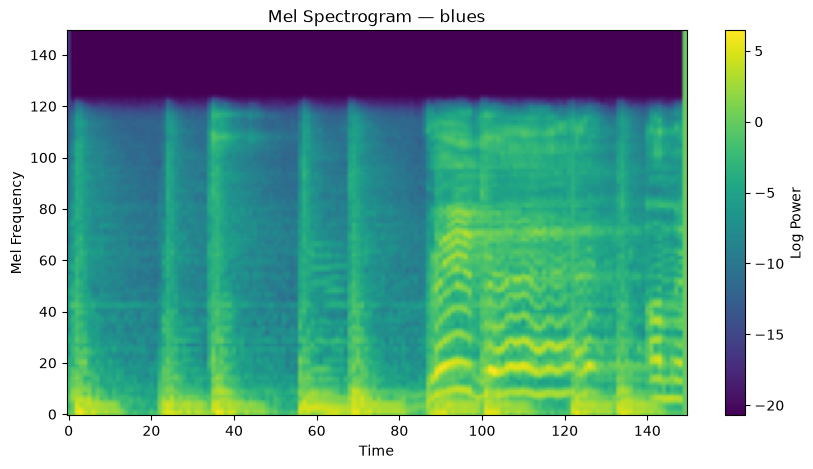

In [31]:
spectrogram = spectrograms[0]

plt.figure(figsize=(10, 5))
plt.imshow(
    spectrogram,
    aspect="auto",
    origin="lower"
)
plt.title(f"Mel Spectrogram — {GENRES[sample_label]}")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.colorbar(label="Log Power")
plt.show()

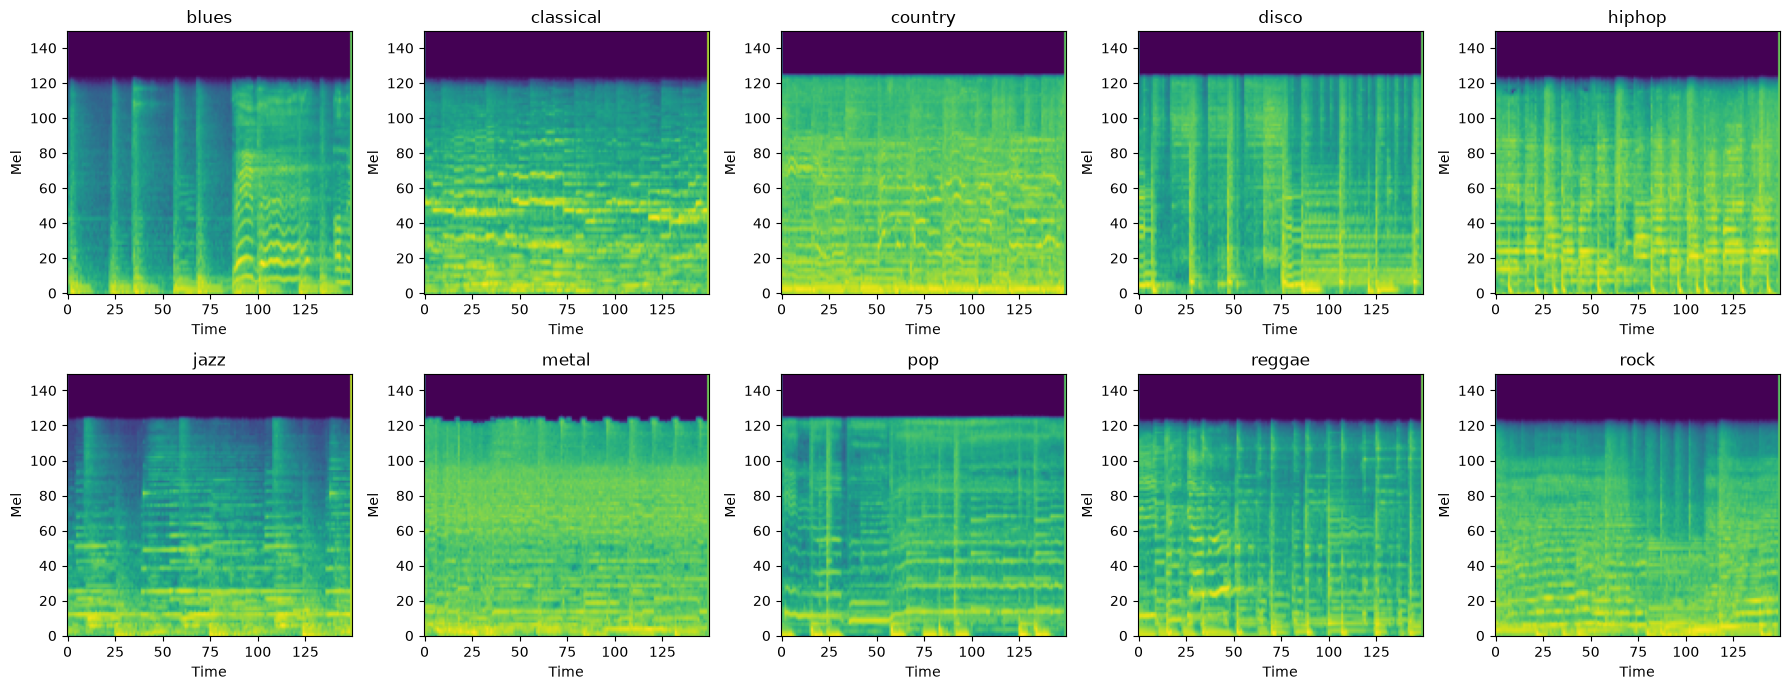

In [32]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, genre in enumerate(GENRES):

    genre_files = [
        (path, label)
        for path, label in train_files
        if label == i
    ]

    path, label = genre_files[0]

    spectrograms = np.load(path)
    spectrogram = spectrograms[0]

    axes.flat[i].imshow(
        spectrogram,
        aspect="auto",
        origin="lower"
    )

    axes.flat[i].set_title(genre)
    axes.flat[i].set_xlabel("Time")
    axes.flat[i].set_ylabel("Mel")

plt.tight_layout()
plt.show()

In [33]:
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4

train_dataset = create_dataset(
    split="train",
    batch_size=BATCH_SIZE,
    shuffle=True,
    repeat=True
)

val_dataset = create_dataset(
    split="val",
    batch_size=BATCH_SIZE,
    shuffle=False,
    repeat=True
)

test_dataset = create_dataset(
    split="test",
    batch_size=BATCH_SIZE,
    shuffle=False,
    repeat=False
)

In [34]:
import math

train_steps = math.ceil(len(train_files) / BATCH_SIZE)
val_steps = math.ceil(len(val_files) / BATCH_SIZE)
test_steps = math.ceil(len(test_files) / BATCH_SIZE)

print("Train steps:", train_steps)
print("Validation steps:", val_steps)
print("Test steps:", test_steps)

Train steps: 22
Validation steps: 5
Test steps: 5


In [35]:
X, y = next(iter(train_dataset))

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)
print("X range:", X.numpy().min(), "to", X.numpy().max())
print("Labels:", y.numpy())

X shape: (32, 150, 150, 1)
y shape: (32,)
X dtype: <dtype: 'float32'>
y dtype: <dtype: 'int32'>
X range: -20.723267 to 8.522256
Labels: [6 4 6 5 0 5 4 7 1 1 0 8 9 2 5 1 5 6 2 0 7 8 1 5 3 0 4 5 3 6 4 7]


In [36]:
model = build_cnn(
    input_shape=(150, 150, 1),
    num_classes=10
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 148, 148, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 15, 15, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 5, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1200)           │     2,458,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        12,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,182,458 (27.40 MB)

 Trainable params: 7,182,458 (27.40 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
MODEL_PATH = PROJECT_ROOT / "models" / "best_cnn.keras"

MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_PATH),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [39]:
# history = model.fit(
#     train_dataset,
#     validation_data=val_dataset,
#     epochs=EPOCHS,
#     steps_per_epoch=train_steps,
#     validation_steps=val_steps,
#     callbacks=[checkpoint]
# )

In [40]:
# plt.figure(figsize=(10, 5))

# plt.plot(history.history["accuracy"], label="Train")
# plt.plot(history.history["val_accuracy"], label="Validation")

# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.title("Training vs Validation Accuracy")
# plt.legend()
# plt.grid()
# plt.show()

In [41]:
# plt.figure(figsize=(10, 5))

# plt.plot(history.history["loss"], label="Train")
# plt.plot(history.history["val_loss"], label="Validation")

# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training vs Validation Loss")
# plt.legend()
# plt.grid()
# plt.show()

In [42]:
# best_model = keras.models.load_model(MODEL_PATH)

# test_loss, test_accuracy = best_model.evaluate(
#     test_dataset,
#     steps=test_steps
# )

# print("Test loss:", test_loss)
# print("Test accuracy:", test_accuracy)

In [43]:
# from collections import defaultdict

# y_true = []
# y_pred = []

# for filepath, label in test_files:

#     spectrograms = np.load(filepath)

#     # Add channel dimension
#     X = spectrograms[..., np.newaxis].astype(np.float32)

#     # Predict all chunks of this track
#     probabilities = best_model.predict(X, verbose=0)

#     # Average predictions across all chunks
#     mean_probability = probabilities.mean(axis=0)

#     predicted_label = np.argmax(mean_probability)

#     y_true.append(label)
#     y_pred.append(predicted_label)

# track_accuracy = np.mean(
#     np.array(y_true) == np.array(y_pred)
# )

# print("Track-level accuracy:", track_accuracy)

In [44]:
# from sklearn.metrics import confusion_matrix, classification_report

# cm = confusion_matrix(y_true, y_pred)

# plt.figure(figsize=(10, 8))

# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     xticklabels=GENRES,
#     yticklabels=GENRES
# )

# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Track-Level Confusion Matrix")

# plt.show()

In [45]:
# from sklearn.metrics import confusion_matrix, classification_report

# cm = confusion_matrix(y_true, y_pred)

# plt.figure(figsize=(10, 8))

# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     xticklabels=GENRES,
#     yticklabels=GENRES
# )

# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Track-Level Confusion Matrix")

# plt.show()

In [46]:
# print(
#     classification_report(
#         y_true,
#         y_pred,
#         target_names=GENRES
#     )
# )

In [47]:
# y_true_np = np.array(y_true)
# y_pred_np = np.array(y_pred)

# for i, genre in enumerate(GENRES):
#     mask = y_true_np == i

#     accuracy = np.mean(
#         y_pred_np[mask] == i
#     )

#     print(f"{genre:10s}: {accuracy:.2%}")

In [48]:
def get_all_chunks(files):
    X = []
    y = []

    for filepath, label in files:
        spectrograms = np.load(filepath)

        for spectrogram in spectrograms:
            X.append(spectrogram)
            y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    X = X[..., np.newaxis]

    return X, y

In [49]:
X_train, y_train = get_all_chunks(train_files)
X_val, y_val = get_all_chunks(val_files)
X_test, y_test = get_all_chunks(test_files)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (9781, 150, 150, 1) (9781,)
Val: (2096, 150, 150, 1) (2096,)
Test: (2100, 150, 150, 1) (2100,)


In [50]:
train_ds_all = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

val_ds_all = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

test_ds_all = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

train_ds_all = (
    train_ds_all
    .shuffle(len(X_train))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_all = (
    val_ds_all
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds_all = (
    test_ds_all
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [51]:
model_all_chunks = build_cnn(
    input_shape=(150, 150, 1),
    num_classes=10
)

model_all_chunks.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [52]:
MODEL_PATH_ALL = PROJECT_ROOT / "models" / "cnn_all_chunks.keras"

checkpoint_all = keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_PATH_ALL),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [53]:
history_all = model_all_chunks.fit(
    train_ds_all,
    validation_data=val_ds_all,
    epochs=30,
    callbacks=[checkpoint_all]
)

Epoch 1/30


c:\Users\Mohal\Documents\Projects\music-genre-classifier\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3273 - loss: 1.7972
Epoch 1: val_accuracy improved from None to 0.51574, saving model to c:\Users\Mohal\Documents\Projects\music-genre-classifier\models\cnn_all_chunks.keras

Epoch 1: finished saving model to c:\Users\Mohal\Documents\Projects\music-genre-classifier\models\cnn_all_chunks.keras
306/306 ━━━━━━━━━━━━━━━━━━━━ 414s 1s/step - accuracy: 0.3273 - loss: 1.7972 - val_accuracy: 0.5157 - val_loss: 1.3790
Epoch 2/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5339 - loss: 1.2797
Epoch 2: val_accuracy improved from 0.51574 to 0.55487, saving model to c:\Users\Mohal\Documents\Projects\music-genre-classifier\models\cnn_all_chunks.keras

Epoch 2: finished saving model to c:\Users\Mohal\Documents\Projects\music-genre-classifier\models\cnn_all_chunks.keras
306/306 ━━━━━━━━━━━━━━━━━━━━ 481s 2s/step - accuracy: 0.5339 - loss: 1.2797 - val_accuracy: 0.5549 - val_loss: 1.2205
Epoch 3/30
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - a

In [54]:
from tensorflow import keras

best_model_all = keras.models.load_model(MODEL_PATH_ALL)

In [55]:
test_loss, test_acc = best_model_all.evaluate(
    test_ds_all,
    verbose=1
)

print("Chunk-level test accuracy:", test_acc)

66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 339ms/step - accuracy: 0.7814 - loss: 1.0630
Chunk-level test accuracy: 0.7814285755157471


In [56]:
y_true_all = []
y_pred_all = []

for filepath, label in test_files:
    spectrograms = np.load(filepath)

    X = spectrograms[..., np.newaxis].astype(np.float32)

    probabilities = best_model_all.predict(
        X,
        verbose=0
    )

    # Average predictions across all chunks of this song
    mean_probability = probabilities.mean(axis=0)

    predicted_label = np.argmax(mean_probability)

    y_true_all.append(label)
    y_pred_all.append(predicted_label)

track_accuracy_all = np.mean(
    np.array(y_true_all) == np.array(y_pred_all)
)

print(f"Track-level accuracy: {track_accuracy_all:.2%}")

Track-level accuracy: 84.00%


In [57]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_all,
        y_pred_all,
        target_names=GENRES
    )
)

              precision    recall  f1-score   support

       blues       0.82      0.93      0.88        15
   classical       0.94      1.00      0.97        15
     country       0.69      0.73      0.71        15
       disco       0.80      0.80      0.80        15
      hiphop       0.87      0.87      0.87        15
        jazz       1.00      0.87      0.93        15
       metal       0.92      0.80      0.86        15
         pop       1.00      0.93      0.97        15
      reggae       0.79      0.73      0.76        15
        rock       0.65      0.73      0.69        15

    accuracy                           0.84       150
   macro avg       0.85      0.84      0.84       150
weighted avg       0.85      0.84      0.84       150



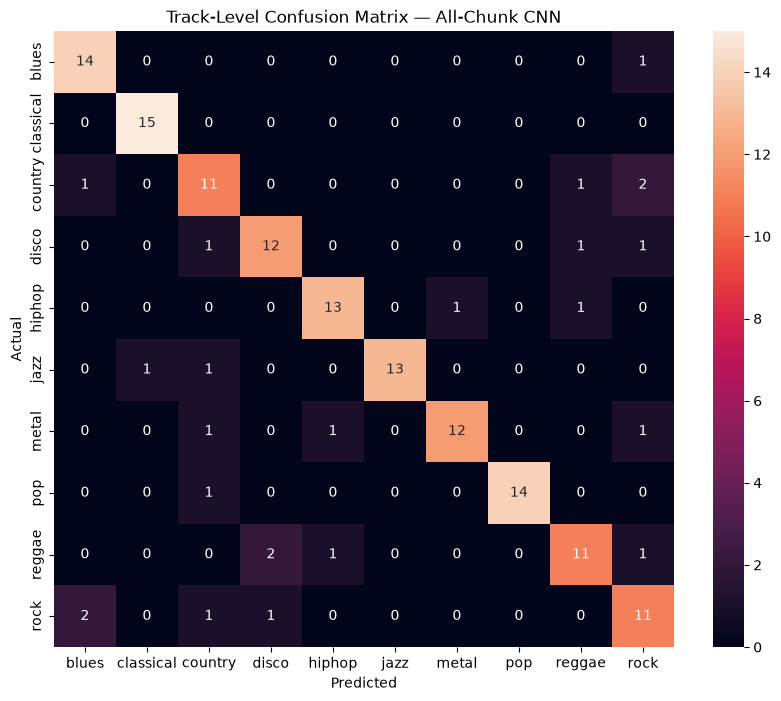

In [58]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_all = confusion_matrix(y_true_all, y_pred_all)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_all,
    annot=True,
    fmt="d",
    xticklabels=GENRES,
    yticklabels=GENRES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Track-Level Confusion Matrix — All-Chunk CNN")
plt.show()

In [59]:
y_true_np = np.array(y_true_all)
y_pred_np = np.array(y_pred_all)

for i, genre in enumerate(GENRES):
    mask = y_true_np == i
    accuracy = np.mean(y_pred_np[mask] == i)

    print(f"{genre:10s}: {accuracy:.2%}")

blues     : 93.33%
classical : 100.00%
country   : 73.33%
disco     : 80.00%
hiphop    : 86.67%
jazz      : 86.67%
metal     : 80.00%
pop       : 93.33%
reggae    : 73.33%
rock      : 73.33%


In [60]:
experiment_results = {
    "experiment": "All chunks",
    "chunk_test_accuracy": float(test_acc),
    "track_test_accuracy": float(track_accuracy_all),
    "macro_f1": 0.83
}

experiment_results

{'experiment': 'All chunks',
 'chunk_test_accuracy': 0.7814285755157471,
 'track_test_accuracy': 0.84,
 'macro_f1': 0.83}

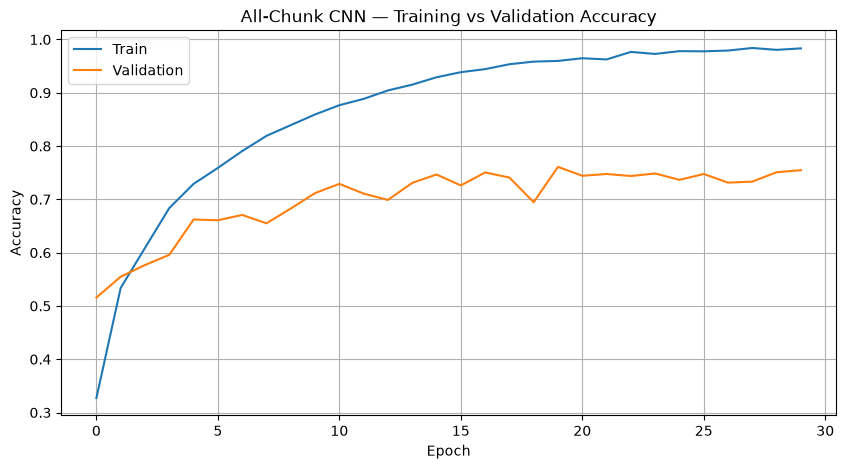

In [61]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_all.history["accuracy"],
    label="Train"
)

plt.plot(
    history_all.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("All-Chunk CNN — Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

In [62]:
history_all

In [63]:
for i, actual in enumerate(GENRES):
    for j, predicted in enumerate(GENRES):
        if i != j and cm_all[i, j] > 0:
            print(
                f"{actual:10s} -> {predicted:10s}: "
                f"{cm_all[i, j]}"
            )

blues      -> rock      : 1
country    -> blues     : 1
country    -> reggae    : 1
country    -> rock      : 2
disco      -> country   : 1
disco      -> reggae    : 1
disco      -> rock      : 1
hiphop     -> metal     : 1
hiphop     -> reggae    : 1
jazz       -> classical : 1
jazz       -> country   : 1
metal      -> country   : 1
metal      -> hiphop    : 1
metal      -> rock      : 1
pop        -> country   : 1
reggae     -> disco     : 2
reggae     -> hiphop    : 1
reggae     -> rock      : 1
rock       -> blues     : 2
rock       -> country   : 1
rock       -> disco     : 1


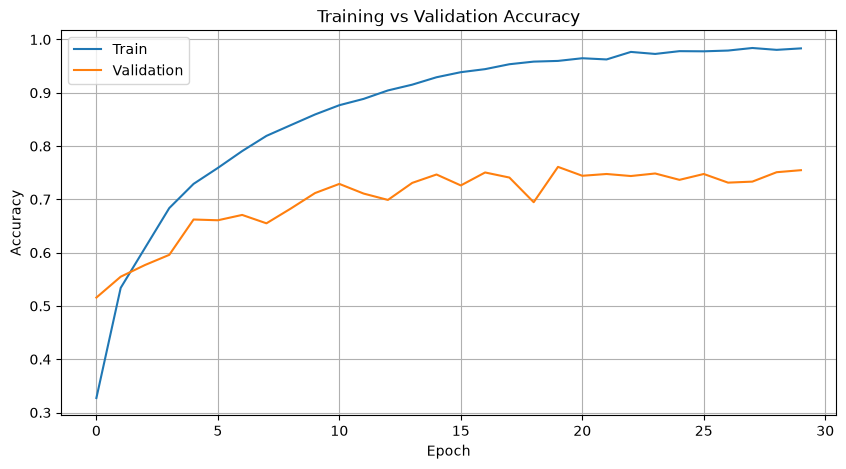

In [66]:
plt.figure(figsize=(10, 5))

plt.plot(history_all.history["accuracy"], label="Train")
plt.plot(history_all.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

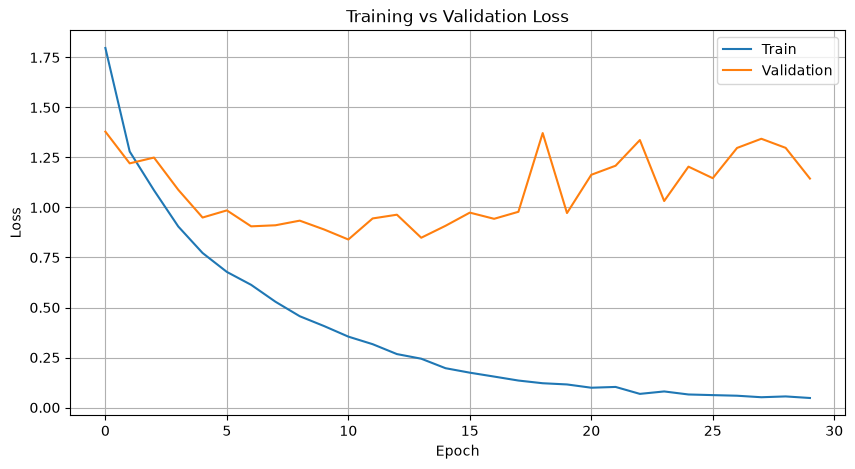

In [65]:
plt.figure(figsize=(10, 5))

plt.plot(history_all.history["loss"], label="Train")
plt.plot(history_all.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [67]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_all,
        y_pred_all,
        target_names=GENRES
    )
)

              precision    recall  f1-score   support

       blues       0.82      0.93      0.88        15
   classical       0.94      1.00      0.97        15
     country       0.69      0.73      0.71        15
       disco       0.80      0.80      0.80        15
      hiphop       0.87      0.87      0.87        15
        jazz       1.00      0.87      0.93        15
       metal       0.92      0.80      0.86        15
         pop       1.00      0.93      0.97        15
      reggae       0.79      0.73      0.76        15
        rock       0.65      0.73      0.69        15

    accuracy                           0.84       150
   macro avg       0.85      0.84      0.84       150
weighted avg       0.85      0.84      0.84       150



In [68]:
from sklearn.metrics import confusion_matrix

cm_all = confusion_matrix(y_true_all, y_pred_all)

print(cm_all)

[[14  0  0  0  0  0  0  0  0  1]
 [ 0 15  0  0  0  0  0  0  0  0]
 [ 1  0 11  0  0  0  0  0  1  2]
 [ 0  0  1 12  0  0  0  0  1  1]
 [ 0  0  0  0 13  0  1  0  1  0]
 [ 0  1  1  0  0 13  0  0  0  0]
 [ 0  0  1  0  1  0 12  0  0  1]
 [ 0  0  1  0  0  0  0 14  0  0]
 [ 0  0  0  2  1  0  0  0 11  1]
 [ 2  0  1  1  0  0  0  0  0 11]]
